# Imaginary-Time Filtering with an Exponential Polynomial

Imaginary-time evolution applies a transform proportional to

$$e^{-\beta H}.$$

It suppresses high-energy components relative to low-energy components, which is useful for cooling intuition, thermal filtering, and ground-state preparation heuristics. This notebook approximates the spectral transform with a bounded polynomial.

## Problem, QSVT Strategy, and Quantum Relevance

**System/problem.** This notebook studies a small three-level Hamiltonian.

**QSVT implementation.** It approximates an imaginary-time exponential as a bounded polynomial transform. The matrices are deliberately small so the spectral rescaling, polynomial target, and validation quantities are visible in one executable notebook.

**Classical reference and quantum relevance.** Exact spectral exponentiation validates the cooled state. Imaginary-time filtering is a core route to ground-state preparation when the Hamiltonian can be block encoded, although this small notebook is only a classical simulation of the primitive.


## Variable definitions

- `H`: three-level Hamiltonian.
- `energies`, `eigenvectors`: exact eigenvalues and eigenvectors of `H`.
- `E_min`, `E_max`: minimum and maximum energies.
- `center`, `half_width`: midpoint and half-width of the energy interval.
- `A`: Hamiltonian rescaled so low energy maps toward `+1`.
- `scaled_energies`: eigenvalues of the rescaled Hamiltonian.
- `beta`: imaginary-time filtering strength.
- `coeffs`: exponential polynomial coefficients.
- `P_cool`: polynomial cooling operator.
- `exact_target`: exact bounded exponential target function.
- `P_exact`: exact cooling operator from spectral decomposition.
- `operator_error`: norm difference between polynomial and exact operators.
- `SEED`, `rng`: reproducible random-number setup.
- `psi`, `cooled`, `exact_cooled`: initial, polynomial-cooled, and exact-cooled states.
- `ground_state`: exact ground-state vector.
- `initial_ground_weight`, `cooled_ground_weight`, `exact_ground_weight`: ground-state probabilities.
- `xs`, `fig`, `axes`, `labels`, and `values` are plotting helpers.


In [1]:
import matplotlib.pyplot as plt
import numpy as np

from qsvt.polynomials import eval_polynomial
from qsvt.spectral import (
    apply_function_to_hermitian,
    apply_polynomial_to_hermitian,
    eigh_hermitian,
)
from qsvt.templates import exponential_approximation_polynomial

np.set_printoptions(precision=4, suppress=True)

## A small three-level Hamiltonian

The example uses a non-diagonal Hamiltonian with known exact spectral reference obtained by diagonalization.

In [2]:
H = np.array(
    [
        [0.25, -0.18, 0.05],
        [-0.18, 0.85, -0.22],
        [0.05, -0.22, 1.45],
    ],
    dtype=float,
)

energies, eigenvectors = eigh_hermitian(H)
print(f"Energies [model energy units]: {energies}")

Energies [model energy units]: [0.2    0.8193 1.5306]


## Rescale to the QSVT interval

Map the energy interval to `[-1, 1]`. Low energy maps to `+1`, high energy maps to `-1`, so an increasing exponential in the scaled variable behaves like `exp(-beta H)` up to an overall normalization.

In [3]:
E_min = energies[0]
E_max = energies[-1]
center = 0.5 * (E_min + E_max)
half_width = 0.5 * (E_max - E_min)

A = (center * np.eye(H.shape[0]) - H) / half_width
scaled_energies = np.linalg.eigvalsh(A)

print(f"Scaled Energies [scaled model energy units]: {scaled_energies}")

Scaled Energies [scaled model energy units]: [-1.      0.0691  1.    ]


## Build the bounded exponential transform

`exponential_approximation_polynomial` approximates `exp(beta x - |beta|)`, which remains bounded by 1 on `[-1, 1]`. The normalization does not affect the cooled state's direction after renormalization.

In [4]:
beta = 2.5
degree = 14

coeffs = exponential_approximation_polynomial(degree=degree, beta=beta)
P_cool = apply_polynomial_to_hermitian(A, coeffs)

exact_target = lambda x: np.exp(beta * x - abs(beta))
P_exact = apply_function_to_hermitian(A, exact_target)

operator_error = np.linalg.norm(P_cool - P_exact)
print(f"Operator Error: {operator_error}")

Operator Error: 1.852552687200035e-11


## Cool a trial state

Compare the ground-state probability before and after applying the polynomial cooling transform.

In [5]:
SEED = 0
rng = np.random.default_rng(SEED)
psi = rng.normal(size=H.shape[0])
psi = psi / np.linalg.norm(psi)

cooled = P_cool @ psi
cooled = cooled / np.linalg.norm(cooled)

exact_cooled = P_exact @ psi
exact_cooled = exact_cooled / np.linalg.norm(exact_cooled)

ground_state = eigenvectors[:, 0]
initial_ground_weight = abs(np.vdot(ground_state, psi)) ** 2
cooled_ground_weight = abs(np.vdot(ground_state, cooled)) ** 2
exact_ground_weight = abs(np.vdot(ground_state, exact_cooled)) ** 2

print(f"Initial Ground Weight [probability]: {initial_ground_weight}")
print(f"Cooled Ground Weight [probability]: {cooled_ground_weight}")
print(f"Exact Ground Weight [probability]: {exact_ground_weight}")

Initial Ground Weight [probability]: 0.018745945993631295
Cooled Ground Weight [probability]: 0.9930808704605139
Exact Ground Weight [probability]: 0.9930808704691421


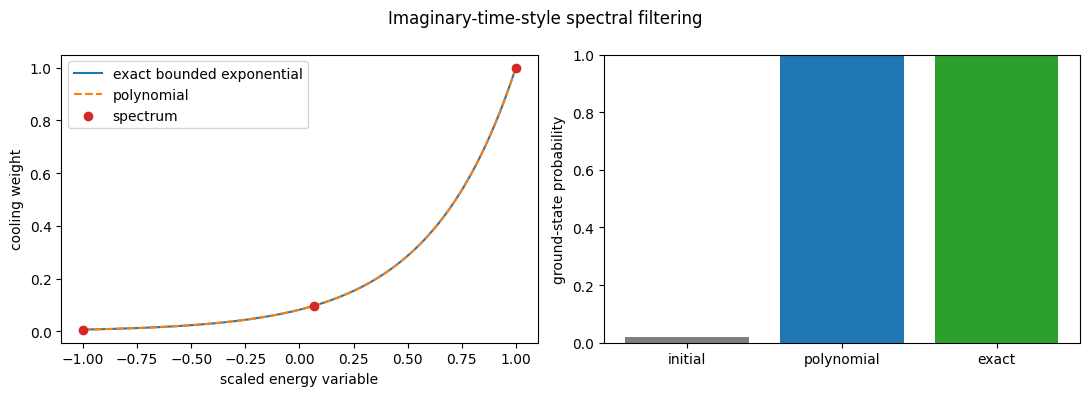

In [6]:
xs = np.linspace(-1, 1, 600)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(xs, exact_target(xs), label="exact bounded exponential")
axes[0].plot(xs, eval_polynomial(coeffs, xs), "--", label="polynomial")
axes[0].scatter(
    scaled_energies,
    exact_target(scaled_energies),
    color="tab:red",
    zorder=3,
    label="spectrum",
)
axes[0].set_xlabel("scaled energy variable")
axes[0].set_ylabel("cooling weight")
axes[0].legend()

labels = ["initial", "polynomial", "exact"]
values = [initial_ground_weight, cooled_ground_weight, exact_ground_weight]
axes[1].bar(labels, values, color=["tab:gray", "tab:blue", "tab:green"])
axes[1].set_ylim(0, 1.0)
axes[1].set_ylabel("ground-state probability")

fig.suptitle("Imaginary-time-style spectral filtering")
plt.tight_layout()
plt.show()

## What this demonstrates

The polynomial approximates the bounded part of imaginary-time evolution. For larger Hamiltonians, the same spectral transform is meaningful once a suitable block encoding and polynomial synthesis route are available.